In [1]:
import pandas as pd
import numpy as np
import requests
import time

url = "https://api.jikan.moe/v4/anime" #the website link to the api im getting data from

 #get request
 #putting the data in a better format


total_set = [] #sourced google/stack overflow goes through all the pages and adds to the data set
url = "https://api.jikan.moe/v4/anime"
for page in range (1,1203): #the range is 20 pages for now but can be extended to the whole dataset would just take a while
    response = requests.get(f"{url}?page={page}") #loops through the pages to collect data
    data = response.json()
    total_set.extend(data["data"]) #this is used instead of append due to how the data us structured since data["data"] returns a list of 25 anime for every page so it would come out like [[Anime 1, Anime 2...], [Anime 26, Anime 27...]] instead of [Anime 1, Anime 2, ..., Anime 26, Anime 27, ...] (Google Gemini was used for this function) 
    time.sleep(1.0) #added to stop me from getting rate limited 3 requests per second allowed by Jikan API so technically the limit is 0.34 but I'll leave room for error
df_data = pd.DataFrame(total_set)[["title","episodes","score","members","year","type",]] # makes a data set with variables
df_data["post y2k"] = np.where(df_data['year']>=2000, '1', '0') #binary variable denoting if it after change of century
df_data["weighted popularity"] = df_data["members"] / df_data["episodes"] #creates variables weighting the amount of members that follow the anime by the amount of episodes it has)
df_data
df_data.to_csv("anime_data_full.csv", index=False)


#3 I would probably want to run a regression with episodes as my x and the score as my y to see how the amount of episodes affects the score and if they are positively correlated
#I also probably want to sort them by only TV since I would think that the Movies would only have one episode unless it had multiple parts
#I can add more controls but right now I have members which is the amount of people who have signed up as a "fan" of the show and then also use year to see whether or not through the different periods of time if the correlation is changed or not



KeyboardInterrupt: 

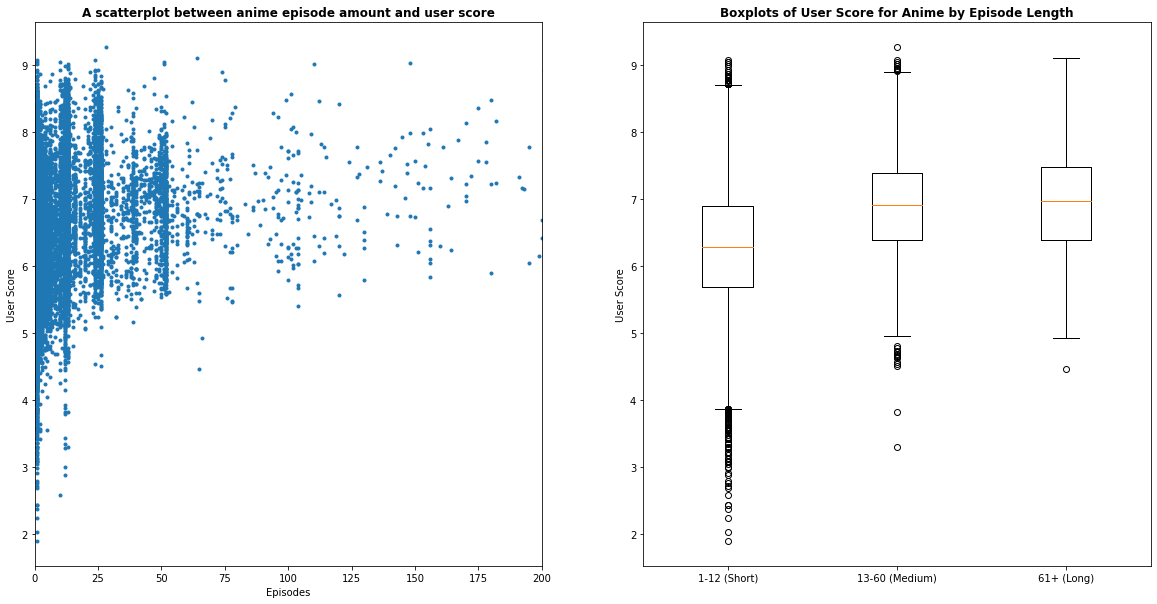

In [4]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
#import the data
anime = pd.read_csv('anime_data_full.csv')
anime = anime.dropna(subset = ['score', 'episodes']) #dropping values that don't exist 
#putting the the two graphs from above together
anime = anime.dropna(subset = ['score', 'episodes']) #gets rid of NaN
short_group = anime[(anime['episodes']<=12)& (anime['episodes']>0)]['score'] #same grouping as beofre
medium_group = anime[(anime['episodes']>=13)& (anime['episodes']<=60)]['score']
long_group = anime[(anime['episodes']>=61)]['score']
plotted_data = [short_group, medium_group, long_group]

plt.figure(figsize=(20,10)) #sets figsize

plt.subplot(1,2,1) #scatterplot doing subplots to separate them
plt.plot('episodes','score', data= anime, linestyle='none', marker='.')
plt.ylabel('User Score')
plt.xlabel('Episodes')
plt.title("A scatterplot between anime episode amount and user score",fontweight='bold')
plt.xlim(0,200)

plt.subplot(1,2,2) #boxplot doing subplots to separate them
plt.boxplot(plotted_data)
plt.ylabel("User Score")
plt.xticks([1,2,3], ['1-12 (Short)', '13-60 (Medium)', '61+ (Long)'])
plt.title("Boxplots of User Score for Anime by Episode Length",fontweight='bold')
plt.savefig('anime_plots1.png', dpi=300) #saves the graphs
plt.show()
#The scatterplot and boxplot show that the episodes that have very little episodes tend to vary a lot in score and tend to be less.
#In contrast, animes with a medium amount of episodes and an large amount of episode tend to be more consistently rated higher by users.

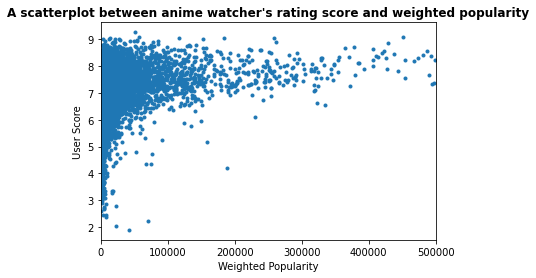

In [5]:
#import the data
anime = pd.read_csv('anime_data_full.csv')
anime = anime.dropna(subset = ['score', 'weighted popularity']) #drops the NaN values

#scatterplot

plt.plot('weighted popularity','score', data= anime, linestyle='none', marker='.') #makes a scatterplot with "weighted popularity" which is popularity/amount of episodes as the x and the score given by viewers is the y

# conditions and labelling
plt.ylabel('User Score')
plt.xlabel('Weighted Popularity')
plt.title("A scatterplot between anime watcher's rating score and weighted popularity",fontweight='bold')
plt.xlim(0,500000) #weighted popularity from 0-500000
 
plt.savefig('anime_weightedpop_plot.png', dpi=300)#saves the graph
plt.show() #showing 

#This shows that most anime is highly rated but the animes with the most weighted popularity are able to still maintain a high user score making those two variables highly correlated
#In general we see that both weighted popularity and amount of episodes seem to lead to a higher user score